# LSTM: Trajectory Regression + 3‑Klassen‑Wurfklassifikation
Dieses Notebook implementiert **genau die gewünschte Aufteilung**:
- **Modus A (noisy)**  (vollständige Sequenz → vollständige Sequenz)
- **Modus B (clean-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste cleanen 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)
- **Modus C (noisy-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste noisy 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)

Es erzeugt synthetische Ballistik‑Trajektorien, baut **Train/Validation/Test**‑Splits, trainiert die Modelle und evaluiert Regression & Klassifikation.


In [28]:

# 0) Imports & Setup
import os, random
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Daten laden

In [29]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
df["point_index"] = df.groupby("wurf_id").cumcount()
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 13)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0', 'point_index']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0,point_index
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672,0
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672,1
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672,2
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672,3
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672,4


In [30]:
# Pro Wurf aggregieren
per_throw = (
    df.groupby("wurf_id")
    .agg({"label": "first", "theta": "first", "v0": "first", "T": "first"})
    .reset_index()
)

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


In [31]:
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

df_train = (
    df[df["wurf_id"].isin(train_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_val = (
    df[df["wurf_id"].isin(val_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_test = (
    df[df["wurf_id"].isin(test_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Scaling (fit auf Train)

In [32]:

class XYScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, xy: np.ndarray):
        self.mean_ = xy.mean(axis=0, keepdims=True)
        self.std_ = xy.std(axis=0, keepdims=True) + 1e-8
        return self

    def transform(self, xy: np.ndarray) -> np.ndarray:
        return (xy - self.mean_) / self.std_

    def inverse_transform(self, xy_scaled: np.ndarray) -> np.ndarray:
        return xy_scaled * self.std_ + self.mean_

# Fit auf clean targets aus Train
train_xy = df_train[["x_clean","y_clean"]].to_numpy(np.float32)
scaler = XYScaler().fit(train_xy)

# Quick sanity: Standardisierung
xy_s = scaler.transform(train_xy)
xy_s.mean(axis=0), xy_s.std(axis=0)


(array([ 2.9947156e-08, -5.0125834e-07], dtype=float32),
 array([1.        , 0.99999994], dtype=float32))

## 4) Dataset

In [33]:
def df_to_wurf_arrays(df: pd.DataFrame):
    # group each wurf into arrays ordered by point_index
    groups = []
    for wid, g in df.groupby("wurf_id"):
        g = g.sort_values("point_index")
        groups.append(g)
    return groups


class ExtrapolationDataset(Dataset):
    """Seq2Seq-Setup **ohne Horizont-/Endzeitpunkt-Wissen im Decoder**.

    - Encoder sieht die ersten Tin Punkte (x,y,t_norm) aus dem Beobachtungsfenster.
    - Decoder bekommt **keine** vollständige Zeitachse t_all, sondern nur ein aus den beobachteten Zeiten
      geschätztes Δt (hier: mittlere Schrittweite in *normalisierter* Zeit).
    - Targets (y_all) enthalten weiterhin die komplette Trajektorie (T,2) als Supervision.
      (Im Training/Eval wird der Regressions-Loss typischerweise nur auf den Zukunftsanteil Tin:… angewandt.)
    """
    def __init__(self, df, scaler, tin, input_source="clean", target_source="clean"):
        self.df = df
        self.scaler = scaler
        self.tin = tin
        self.input_source = input_source
        self.target_source = target_source

        # >>> neu: wurf_id-Liste + Gruppen, damit wir für idx wieder an die Rohdaten kommen
        self.throw_ids = list(self.df["wurf_id"].unique())
        self.groups = {k: g.sort_values("point_index").reset_index(drop=True)
                       for k, g in self.df.groupby("wurf_id")}

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        wid = self.throw_ids[idx]
        g = self.groups[wid]
        label = int(g["label"].iloc[0])

        T = len(g)
        assert self.tin <= T

        # --- time normalization without future knowledge ---
        t = g["t"].to_numpy(np.float32)[:, None]        # (T,1) absolute time (seconds)
        t_min = float(t[0, 0])
        t_obs_max = float(t[self.tin - 1, 0])           # last observed time

        denom = max(1e-8, (t_obs_max - t_min))          # guard against tin==1 or degenerate
        t_n = (t - t_min) / denom                       # observed in [0,1], future > 1
        # --------------------------------------------------

        # Δt ausschließlich aus dem Beobachtungsfenster (Tin) ableiten
        if self.tin >= 2:
            dt_n = float(np.mean(np.diff(t_n[: self.tin, 0])))
        else:
            dt_n = 0.0

        xy_clean = g[["x_clean","y_clean"]].to_numpy(np.float32)
        xy_noisy = g[["x_noisy","y_noisy"]].to_numpy(np.float32)

        xy_in  = xy_noisy if self.input_source=="noisy" else xy_clean
        xy_tgt = xy_clean if self.target_source=="clean" else xy_noisy

        xy_in_s  = self.scaler.transform(xy_in)    # (T,2)
        xy_tgt_s = self.scaler.transform(xy_tgt)   # (T,2)

        # Encoder input: (Tin,3) = [x,y,t_norm]
        x_in = np.concatenate([xy_in_s[:self.tin], t_n[:self.tin]], axis=1).astype(np.float32)

        # Full targets: (T,2)
        y_all = xy_tgt_s.astype(np.float32)

        return (
            torch.from_numpy(x_in),                                 # (Tin,3)
            torch.tensor([dt_n], dtype=torch.float32),              # (1,)
            torch.from_numpy(y_all),                                # (T,2)
            torch.tensor(label, dtype=torch.long)
        )


def collate_extrap(batch):
    # Pads are not needed: Tin and T are fixed by construction.
    x_in, dt, y_all, labels = zip(*batch)
    return (
        torch.stack(x_in, dim=0),     # (B,Tin,3)
        torch.stack(dt, dim=0),       # (B,1)
        torch.stack(y_all, dim=0),    # (B,T,2)
        torch.stack(labels, dim=0),   # (B,)
    )


## 5) Modelle

In [34]:
class ExtrapSeq2SeqModel(nn.Module):
    """Seq2Seq-LSTM für Trajektorien-Regression + 3-Klassen-Classification **ohne Decoder-Horizontwissen**.

    - Encoder: sieht die ersten Tin Punkte (x,y,t_norm).
    - Decoder: autoregressiv, Input pro Schritt: [prev_x, prev_y, Δt]
      wobei Δt ausschließlich aus den beobachteten Zeiten geschätzt wird.
    - Inferenz kann dynamisch bis zur Korbebene (y = h_ring) gerollt werden.

    Decoder wird im Beobachtungsfenster teacher-forced gewärmt und ist ab Extrapolation strikt autoregressiv (kein Teacher Forcing auf zukünftigen Punkten).
    """

    def __init__(self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
        )
        # Decoder bekommt: prev_xy (2) + dt (1) => 3
        self.dec_cell = nn.LSTMCell(input_size=3, hidden_size=hidden_dim)
        self.out_head = nn.Linear(hidden_dim, 2)
        self.cls_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, x_in, dt, n_future: int = 0):
        """Forward-Pass ohne GT-Horizontwissen.

        Args:
          x_in:    (B,Tin,3) = [x,y,t_norm] aus dem Beobachtungsfenster
          dt:      (B,1)     = Δt geschätzt nur aus beobachteten Zeiten (normalisierte Zeit)
          n_future: int      = Anzahl Zukunftsschritte, die *immer* ausgerollt werden
                              (Hyperparameter / Sicherheitsgrenze; **nicht** aus y_all oder T abgeleitet)

        Returns:
          y_hat_full: (B,Tin+n_future,2)  (erste Tin Punkte = Input-XY; danach Decoder-Preds)
          logits:     (B,3)
        """
        out, (hN, cN) = self.enc(x_in)      # out: (B,Tin,H)
        h = hN[-1]                           # (B,H)
        c = cN[-1]

        logits = self.cls_head(h)            # (B,3)

        B, Tin, _ = x_in.shape

        # ----------------------------
        # 1) Teacher-forced Warm-up über den beobachteten Teil (ohne Loss-Zwang)
        # ----------------------------
        prev_xy = x_in[:, 0, :2]  # (B,2) scaled

        for k in range(1, Tin):
            dec_in = torch.cat([prev_xy, dt], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            prev_xy = x_in[:, k, :2]                  # teacher forcing im Beobachtungsfenster

        # ----------------------------
        # 2) Autoregressiver Rollout für Zukunftsschritte (ohne Teacher Forcing)
        # ----------------------------
        preds_f = []
        for _ in range(int(n_future)):
            dec_in = torch.cat([prev_xy, dt], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            xy_next = self.out_head(h)                # (B,2)
            preds_f.append(xy_next.unsqueeze(1))
            prev_xy = xy_next                         # **immer** autoregressiv

        if int(n_future) > 0:
            y_future = torch.cat(preds_f, dim=1)      # (B,n_future,2)
            y_hat_full = torch.cat([x_in[:, :, :2], y_future], dim=1)
        else:
            y_hat_full = x_in[:, :, :2]

        return y_hat_full, logits

    @torch.no_grad()
    def rollout_until_ring(self, x_in, dt, y_ring_scaled, max_steps=300):
        """Autoregressiver Rollout bis zur Korbebene ohne Horizontwissen im Decoder-Input.

        Ablauf:
          1) Encoder verarbeitet das Beobachtungsfenster.
          2) Decoder-State wird im Beobachtungsfenster teacher-forced gewärmt (nur beobachtete Punkte als Input).
          3) Ab Extrapolation strikt autoregressiver Rollout bis zur ersten *absteigenden* Schnittstelle
             y <= y_ring_scaled (nach Passieren des Apex). Falls Apex bereits im Beobachtungsfenster passiert wurde,
             wird dies berücksichtigt.

        Returns:
          y_future: (B,S,2) Preds für Zukunftsschritte (S <= max_steps)
          stop_idx: (B,) Index (0..S-1) des Stop-Schritts im Zukunftstensor (falls nie: letzter Schritt)
          S:        int, tatsächliche Anzahl ausgegebener Steps
        """
        self.eval()
        
        # Guard: kein Rollout, falls max_steps <= 0
        if max_steps is None or int(max_steps) <= 0:
            y_future = torch.zeros((x_in.size(0), 0, 2), device=x_in.device)
            stop_idx = torch.full((x_in.size(0),), -1, dtype=torch.long, device=x_in.device)
            return y_future, stop_idx, 0

        out, (hN, cN) = self.enc(x_in)
        h = hN[-1]
        c = cN[-1]

        B, Tin, _ = x_in.shape

        # ----------------------------
        # Warm-up im Beobachtungsfenster (teacher-forced)
        # ----------------------------
        prev_xy = x_in[:, 0, :2]
        for k in range(1, Tin):
            dec_in = torch.cat([prev_xy, dt], dim=1)
            h, c = self.dec_cell(dec_in, (h, c))
            prev_xy = x_in[:, k, :2]

        # Start für Zukunftsrollout: letzter beobachteter Punkt
        prev_xy = x_in[:, -1, :2]
        prev_y = prev_xy[:, 1:2]

        # Apex-Status initialisieren: wenn die letzten beobachteten Punkte bereits fallend sind -> Apex passiert
        if Tin >= 2:
            dy_obs = x_in[:, -1, 1] - x_in[:, -2, 1]
            passed_apex = (dy_obs < 0).to(torch.bool)
        else:
            passed_apex = torch.zeros(B, dtype=torch.bool, device=x_in.device)
        
        # Guard: falls der letzte beobachtete Punkt bereits nach dem Apex auf/unter Ringhöhe liegt,
        # ist keine Extrapolation nötig.
        already_done = passed_apex & (prev_y <= y_ring_scaled)
        if torch.all(already_done):
            y_future = torch.zeros((B, 0, 2), device=x_in.device)
            stop_idx = torch.full((B,), -1, dtype=torch.long, device=x_in.device)
            return y_future, stop_idx, 0

        preds = []
        stop_idx = torch.full((B,), fill_value=max_steps - 1, dtype=torch.long, device=x_in.device)
        stopped = torch.zeros(B, dtype=torch.bool, device=x_in.device)

        for step in range(max_steps):
            dec_in = torch.cat([prev_xy, dt], dim=1)
            h, c = self.dec_cell(dec_in, (h, c))
            xy = self.out_head(h)
            preds.append(xy.unsqueeze(1))

            y = xy[:, 1:2]
            dy = y - prev_y
            passed_apex = passed_apex | (dy < 0)

            stop_now = (~stopped) & passed_apex & (y <= y_ring_scaled)
            stop_idx = torch.where(stop_now, torch.full_like(stop_idx, step), stop_idx)
            stopped = stopped | stop_now

            prev_xy = xy
            prev_y = y

            if torch.all(stopped):
                break

        y_future = torch.cat(preds, dim=1) if preds else torch.zeros((B,0,2), device=x_in.device)
        S = int(y_future.size(1))
        return y_future, stop_idx, S


## 6) Training & Evaluation Helpers

In [35]:
def _get_scaler_or_raise(scaler):
    if scaler is None:
        scaler = globals().get("scaler", None)
    if scaler is None:
        raise RuntimeError("Kein 'scaler' verfügbar. Übergib ihn an train_extrap/eval_extrap oder definiere ihn global.")
    return scaler


def y_ring_scaled_from_scaler(scaler, y_ring_m: float = 3.048) -> float:
    """Konvertiert Korbhöhe (Meter) in den skalierten y-Raum (Standardisierung via XYScaler)."""
    mean_y = float(scaler.mean_[0, 1])
    std_y  = float(scaler.std_[0, 1])
    return (float(y_ring_m) - mean_y) / std_y


def ring_crossing_index_after_apex(y_seq: torch.Tensor, y_ring_scaled: float) -> torch.Tensor:
    """Ermittelt pro Sample den ersten Index k der (absteigenden) Schnittstelle y[k] <= y_ring nach dem Apex.

    Args:
      y_seq: (B,T) y-Koordinate (skaliert)
      y_ring_scaled: float

    Returns:
      stop_idx: (B,) int64 in [0, T-1]
    """
    B, T = y_seq.shape
    device = y_seq.device

    # Apex index
    apex = torch.argmax(y_seq, dim=1)  # (B,)

    # Crossing candidates between consecutive points: k is the *right* index (1..T-1)
    y0 = y_seq[:, :-1]
    y1 = y_seq[:, 1:]
    cross = (y1 <= y_ring_scaled) & (y0 > y_ring_scaled)  # (B,T-1)

    idxs = torch.arange(T - 1, device=device).unsqueeze(0).expand(B, -1)  # corresponds to y1 index shift
    k_right = idxs + 1  # actual index in original sequence

    # enforce: only after apex
    cross_after = cross & (k_right > apex.unsqueeze(1))

    big = torch.full_like(k_right, fill_value=T, dtype=torch.long)
    first = torch.where(cross_after, k_right, big)  # (B,T-1)
    stop_idx = torch.min(first, dim=1).values       # (B,)

    # if none found, fall back to last available index
    stop_idx = torch.where(stop_idx >= T, torch.full_like(stop_idx, T - 1), stop_idx)
    return stop_idx


def predicted_ring_stop_idx_future(y_hat_full: torch.Tensor, y_ring_scaled: float, tin: int) -> torch.Tensor:
    """Stop-Index im Future-Teil basierend auf der *Prediction* (kein GT-/T-Wissen).

    Args:
      y_hat_full: (B, tin+S, 2) skaliert (erste tin Punkte = Observations, danach Future-Preds)
      y_ring_scaled: float (Ringhöhe im skalierten y-Raum)
      tin: int

    Returns:
      stop_idx_f: (B,) int64 in [0, S-1] (Index relativ zum Future-Teil)
    """
    y_seq = y_hat_full[:, :, 1]  # (B, tin+S)
    B, Ttot = y_seq.shape
    device = y_seq.device
    apex = torch.argmax(y_seq, dim=1)  # (B,)

    idxs = torch.arange(Ttot, device=device).unsqueeze(0).expand(B, -1)
    cross = (idxs > apex.unsqueeze(1)) & (idxs >= tin) & (y_seq <= y_ring_scaled)

    big = torch.full_like(idxs, fill_value=Ttot, dtype=torch.long)
    first = torch.where(cross, idxs, big)
    stop = torch.min(first, dim=1).values  # (B,)

    # if never crosses: stop at last future step
    stop = torch.where(stop >= Ttot, torch.full_like(stop, Ttot - 1), stop)

    S = max(0, Ttot - tin)
    stop_f = stop - tin
    stop_f = torch.clamp(stop_f, min=0, max=max(0, S - 1))
    return stop_f.long()


def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """MSE über maskierte Zeitpunkte.
    pred/target: (B,S,2), mask: (B,S) bool/float
    """
    # expand mask to xy dims
    m = mask.unsqueeze(-1).to(pred.dtype)  # (B,S,1)
    se = (pred - target) ** 2
    denom = torch.sum(m) * pred.size(-1) + 1e-8
    return torch.sum(se * m) / denom


def train_extrap(
    model: ExtrapSeq2SeqModel,
    train_loader: DataLoader,
    val_loader: DataLoader,
    tin: int = 30,
    max_future_steps: int = 200,
    epochs: int = 25,
    lr: float = 2e-3,
    cls_weight: float = 0.2,
    y_ring_m: float = 3.048,
    scaler=None,
    verbose: bool = True,
):
    """Training ohne GT-Horizontwissen (kein T_out = T).

    - Modell rollt IMMER exakt `max_future_steps` Zukunftsschritte aus (Hyperparameter/Sicherheitsgrenze).
    - Regressions-Loss wird bis zur vorhergesagten Ring-Schnittstelle (nach Apex) maskiert.
      Die Maske wird ausschließlich aus der *Prediction* berechnet (kein GT-Stoppindex).

    Hinweis: Damit das funktioniert, müssen Targets `y_all` mindestens `tin + max_future_steps` lang sein
    (oder du ergänzt Padding/Valid-Masken).
    """
    scaler = _get_scaler_or_raise(scaler)
    y_ring_s = y_ring_scaled_from_scaler(scaler, y_ring_m=y_ring_m)

    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "tr_loss": [],
        "va_loss": [],
        "tr_acc": [],
        "va_acc": [],
        "tr_mse_future": [],
        "va_mse_future": [],
    }

    best = {"loss": float("inf"), "state": None}

    for ep in range(1, epochs + 1):
        # ---------------- train ----------------
        model.train()
        tr_losses = []
        tr_y, tr_p = [], []
        tr_mse_f = []

        for x_in, dt, y_all, c in train_loader:
            x_in = x_in.to(device)
            dt = dt.to(device)
            y_all = y_all.to(device)
            c = c.to(device)

            Tin = int(x_in.size(1))
            n_future = int(max_future_steps)

            if int(y_all.size(1)) < Tin + n_future:
                raise ValueError(
                    f"y_all zu kurz: T={int(y_all.size(1))} < Tin+max_future_steps={Tin+n_future}. "
                    "Wähle max_future_steps kleiner oder padde/trimme die Targets im Dataset."
                )

            yhat, logits = model(x_in, dt, n_future=n_future)

            # future slices (fixed length)
            pred_f = yhat[:, Tin:Tin + n_future, :]
            tgt_f  = y_all[:, Tin:Tin + n_future, :]

            # mask until *predicted* ring crossing (after apex)
            stop_f = predicted_ring_stop_idx_future(yhat, y_ring_s, Tin)  # (B,)
            ar = torch.arange(n_future, device=device).unsqueeze(0)        # (1,S)
            mask = ar <= stop_f.unsqueeze(1)                               # (B,S)

            loss_reg = masked_mse(pred_f, tgt_f, mask)
            future_mse = loss_reg.detach().item()

            loss_cls = F.cross_entropy(logits, c)
            loss = loss_reg + cls_weight * loss_cls

            opt.zero_grad()
            loss.backward()
            opt.step()

            tr_losses.append(loss.item())
            tr_mse_f.append(future_mse)
            tr_y.extend(c.detach().cpu().tolist())
            tr_p.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

        tr_acc = accuracy_score(tr_y, tr_p)

        # ---------------- val ----------------
        model.eval()
        va_losses = []
        va_y, va_p = [], []
        va_mse_f = []

        with torch.no_grad():
            for x_in, dt, y_all, c in val_loader:
                x_in = x_in.to(device)
                dt = dt.to(device)
                y_all = y_all.to(device)
                c = c.to(device)

                Tin = int(x_in.size(1))
                n_future = int(max_future_steps)

                if int(y_all.size(1)) < Tin + n_future:
                    raise ValueError(
                        f"[VAL] y_all zu kurz: T={int(y_all.size(1))} < Tin+max_future_steps={Tin+n_future}."
                    )

                yhat, logits = model(x_in, dt, n_future=n_future)

                pred_f = yhat[:, Tin:Tin + n_future, :]
                tgt_f  = y_all[:, Tin:Tin + n_future, :]

                stop_f = predicted_ring_stop_idx_future(yhat, y_ring_s, Tin)
                ar = torch.arange(n_future, device=device).unsqueeze(0)
                mask = ar <= stop_f.unsqueeze(1)

                loss_reg = masked_mse(pred_f, tgt_f, mask)
                future_mse = loss_reg.detach().item()

                loss_cls = F.cross_entropy(logits, c)
                loss = loss_reg + cls_weight * loss_cls

                va_losses.append(loss.item())
                va_mse_f.append(future_mse)

                va_y.extend(c.cpu().tolist())
                va_p.extend(torch.argmax(logits, dim=1).cpu().tolist())

        va_acc = accuracy_score(va_y, va_p)

        tr_loss = float(np.mean(tr_losses)) if tr_losses else 0.0
        va_loss = float(np.mean(va_losses)) if va_losses else 0.0

        hist["tr_loss"].append(tr_loss)
        hist["va_loss"].append(va_loss)
        hist["tr_acc"].append(tr_acc)
        hist["va_acc"].append(va_acc)
        hist["tr_mse_future"].append(float(np.mean(tr_mse_f)) if tr_mse_f else 0.0)
        hist["va_mse_future"].append(float(np.mean(va_mse_f)) if va_mse_f else 0.0)

        if va_loss < best["loss"]:
            best["loss"] = va_loss
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[C] ep={ep:02d} tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} "
                f"| tr_acc={tr_acc:.3f} va_acc={va_acc:.3f} "
                f"| va_future_mse(masked,pred-stop)={hist['va_mse_future'][-1]:.5f}"
            )

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return hist
def eval_extrap(
    model: ExtrapSeq2SeqModel,
    loader: DataLoader,
    tin: int = 30,
    max_future_steps: int = 200,
    split_name: str = "test",
    y_ring_m: float = 3.048,
    scaler=None,
):
    """Evaluation ohne GT-Horizontwissen (kein T_out = T).

    - Modell rollt exakt `max_future_steps` Zukunftsschritte aus.
    - Future-MSE wird bis zur *vorhergesagten* Ring-Schnittstelle maskiert (nach Apex).
    """
    scaler = _get_scaler_or_raise(scaler)
    y_ring_s = y_ring_scaled_from_scaler(scaler, y_ring_m=y_ring_m)

    model.eval()
    all_y, all_p = [], []
    mse_future_masked = []

    with torch.no_grad():
        for x_in, dt, y_all, c in loader:
            x_in = x_in.to(device)
            dt = dt.to(device)
            y_all = y_all.to(device)
            c = c.to(device)

            Tin = int(x_in.size(1))
            n_future = int(max_future_steps)

            if int(y_all.size(1)) < Tin + n_future:
                raise ValueError(
                    f"[{split_name}] y_all zu kurz: T={int(y_all.size(1))} < Tin+max_future_steps={Tin+n_future}."
                )

            yhat, logits = model(x_in, dt, n_future=n_future)

            pred_f = yhat[:, Tin:Tin + n_future, :]
            tgt_f  = y_all[:, Tin:Tin + n_future, :]

            stop_f = predicted_ring_stop_idx_future(yhat, y_ring_s, Tin)
            ar = torch.arange(n_future, device=device).unsqueeze(0)
            mask = ar <= stop_f.unsqueeze(1)

            future_mse = masked_mse(pred_f, tgt_f, mask).detach().item()
            mse_future_masked.append(future_mse)

            all_y.extend(c.cpu().tolist())
            all_p.extend(torch.argmax(logits, dim=1).cpu().tolist())

    acc = accuracy_score(all_y, all_p)
    mse_f = float(np.mean(mse_future_masked)) if mse_future_masked else 0.0
    print(f"[{split_name}] acc={acc:.3f} future_mse(masked,pred-stop)={mse_f:.6f}")

    cm = confusion_matrix(all_y, all_p, labels=list(range(3)))

    return {"acc": acc, "future_mse_masked": mse_f, "cm": cm, "y_true": all_y, "y_pred": all_p}

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(
    cm,
    class_names=None,
    normalize: bool = False,
    title: str = "Confusion Matrix",
    ax=None,
    cmap: str = "Blues",
    show: bool = True,
):
    """Plottet eine Confusion Matrix notebook-tauglich.

    Akzeptiert entweder:
      - cm als (N,N)-Array/Tensor (Counts oder bereits normalisiert)
      - oder ein dict wie von eval_extrap(...), das den Key 'cm' enthält
        (optional auch 'y_true'/'y_pred').

    Args:
      cm: array-like (N,N) oder dict
      class_names: Liste von Klassenlabels (Länge N). Default: "0..N-1"
      normalize: True -> zeilenweise Normalisierung (true-class Summe = 1)
      title: Plot-Titel
      ax: optional vorhandene matplotlib-Axes
      cmap: Colormap-Name
      show: plt.show() am Ende ausführen (praktisch im Notebook)

    Returns:
      (fig, ax)
    """
    # --- dict-Unterstützung (eval_extrap gibt ein dict zurück) ---
    if isinstance(cm, dict):
        if "cm" in cm:
            cm = cm["cm"]
        elif ("y_true" in cm) and ("y_pred" in cm):
            cm = confusion_matrix(cm["y_true"], cm["y_pred"], labels=[0, 1, 2])
        else:
            raise ValueError(
                "Wenn 'cm' ein dict ist, muss es entweder den Key 'cm' "
                "oder die Keys ('y_true','y_pred') enthalten."
            )

    cm = np.asarray(cm)
    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError(f"cm muss quadratisch sein (N,N). Erhalten: {cm.shape}")

    n = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(n)]
    if len(class_names) != n:
        raise ValueError(f"class_names muss Länge {n} haben. Erhalten: {len(class_names)}")

    # Für die Heatmap verwenden wir float (matplotlib-freundlich)
    cm_plot = cm.astype(float)

    # Optional normalisieren (pro true-class = Zeile)
    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_plot / row_sums

    created_ax = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.0, 4.3))
    else:
        fig = ax.figure

    im = ax.imshow(cm_plot, interpolation="nearest", cmap=cmap)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Anteil" if normalize else "Anzahl", rotation=90)

    ax.set_title(title)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names)

    # Zellwerte: bei Counts als Integer anzeigen, bei normalize als Float
    fmt = ".2f" if normalize else "d"
    thresh = (cm_plot.max() + cm_plot.min()) / 2.0 if cm_plot.size else 0.0

    for i in range(n):
        for j in range(n):
            val_color = cm_plot[i, j]
            if normalize:
                text = format(cm_plot[i, j], fmt)
            else:
                # cm kann float sein (z.B. durch Casting/Loading). Für Counts robust int anzeigen.
                text = format(int(round(cm[i, j])), fmt)

            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if val_color > thresh else "black"
            )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    fig.tight_layout()

    if show and created_ax:
        plt.show()

    return fig, ax

## 7) Modus A (noisy) mit  ExtrapSeq2SeqModel
Encoder bekommt **Tin=50** noisy Punkte

T_total: 50 | max_future_steps: 0
[C] ep=01 tr_loss=0.2199 va_loss=0.2174 | tr_acc=0.336 va_acc=0.350 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=02 tr_loss=0.2165 va_loss=0.2132 | tr_acc=0.430 va_acc=0.500 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=03 tr_loss=0.2102 va_loss=0.2022 | tr_acc=0.523 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=04 tr_loss=0.1953 va_loss=0.1727 | tr_acc=0.561 va_acc=0.650 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=05 tr_loss=0.1620 va_loss=0.1594 | tr_acc=0.589 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=06 tr_loss=0.1595 va_loss=0.1469 | tr_acc=0.626 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=07 tr_loss=0.1329 va_loss=0.1120 | tr_acc=0.645 va_acc=0.700 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=08 tr_loss=0.1158 va_loss=0.1039 | tr_acc=0.785 va_acc=0.950 | va_future_mse(masked,pred-stop)=0.00000
[C] ep=09 tr_loss=0.1040 va_loss=0.0879 | tr_acc=0.850 va_acc=0.950 | va_future_mse(ma

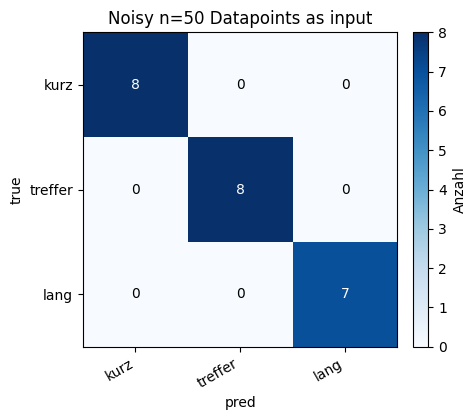

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Noisy n=50 Datapoints as input'}, xlabel='pred', ylabel='true'>)

In [37]:
batch_size = 64

tin = 50

# --- roll-until-ring ohne GT-Horizont: fixe Obergrenze für Future-Rollout ---
# (kein T_out = T; stattdessen Sicherheitsgrenze + pred-basierte Ring-Stop-Maske)
T_total = int(df.groupby("wurf_id").size().min())  # sollte konstant sein ("fixed by construction")
max_future_steps = max(0, T_total - tin)
print("T_total:", T_total, "| max_future_steps:", max_future_steps)


df_train = df[df["wurf_id"].isin(train_ids)].reset_index(drop=True)
df_val   = df[df["wurf_id"].isin(val_ids)].reset_index(drop=True)
df_test  = df[df["wurf_id"].isin(test_ids)].reset_index(drop=True)

dsA_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlA_train = DataLoader(dsA_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlA_val   = DataLoader(dsA_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlA_test  = DataLoader(dsA_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelA = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histA = train_extrap(
    modelA, dlA_train, dlA_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    max_future_steps=max_future_steps
)

# plot_history(histA, "Mode A (extrapolation) - ExtrapSeq2SeqModel")

cmA = eval_extrap(modelA, dlA_test, tin=tin,
    max_future_steps=max_future_steps, split_name="test A")
plot_confusion_matrix(
    cm=cmA,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Noisy n=50 Datapoints as input",
)

## 8) Modus B (clean-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

T_total: 50 | max_future_steps: 20
[C] ep=01 tr_loss=1.0870 va_loss=1.0424 | tr_acc=0.336 va_acc=0.350 | va_future_mse(masked,pred-stop)=0.82498
[C] ep=02 tr_loss=0.9849 va_loss=0.9222 | tr_acc=0.430 va_acc=0.500 | va_future_mse(masked,pred-stop)=0.70886
[C] ep=03 tr_loss=0.8580 va_loss=0.7395 | tr_acc=0.514 va_acc=0.450 | va_future_mse(masked,pred-stop)=0.53617
[C] ep=04 tr_loss=0.6650 va_loss=0.7502 | tr_acc=0.533 va_acc=0.450 | va_future_mse(masked,pred-stop)=0.56066
[C] ep=05 tr_loss=0.6821 va_loss=0.5733 | tr_acc=0.505 va_acc=0.500 | va_future_mse(masked,pred-stop)=0.38373
[C] ep=06 tr_loss=0.5689 va_loss=0.6116 | tr_acc=0.533 va_acc=0.500 | va_future_mse(masked,pred-stop)=0.41688
[C] ep=07 tr_loss=0.5789 va_loss=0.5694 | tr_acc=0.570 va_acc=0.500 | va_future_mse(masked,pred-stop)=0.38811
[C] ep=08 tr_loss=0.5369 va_loss=0.4641 | tr_acc=0.589 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.28654
[C] ep=09 tr_loss=0.4233 va_loss=0.3933 | tr_acc=0.551 va_acc=0.500 | va_future_mse(m

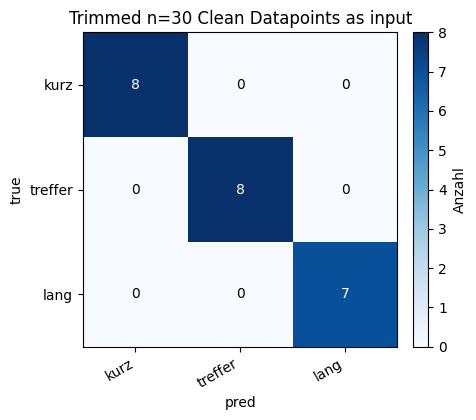

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Trimmed n=30 Clean Datapoints as input'}, xlabel='pred', ylabel='true'>)

In [38]:
tin = 30

# --- roll-until-ring ohne GT-Horizont: fixe Obergrenze für Future-Rollout ---
# (kein T_out = T; stattdessen Sicherheitsgrenze + pred-basierte Ring-Stop-Maske)
T_total = int(df.groupby("wurf_id").size().min())  # sollte konstant sein ("fixed by construction")
max_future_steps = max(0, T_total - tin)
print("T_total:", T_total, "| max_future_steps:", max_future_steps)

dsB_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlB_train = DataLoader(dsB_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlB_val   = DataLoader(dsB_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlB_test  = DataLoader(dsB_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelB = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histB = train_extrap(
    modelB, dlB_train, dlB_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    max_future_steps=max_future_steps
)

# plot_history(histB, "Mode B (extrapolation) - ExtrapSeq2SeqModel")

cmB = eval_extrap(modelB, dlB_test, tin=tin,
    max_future_steps=max_future_steps, split_name="test B")
plot_confusion_matrix(
    cm=cmB,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Trimmed n=30 Clean Datapoints as input",
)

## 9) Modus C (noisy-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** noisy Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

T_total: 50 | max_future_steps: 20
[C] ep=01 tr_loss=1.0760 va_loss=1.0062 | tr_acc=0.364 va_acc=0.400 | va_future_mse(masked,pred-stop)=0.78885
[C] ep=02 tr_loss=0.9679 va_loss=0.8699 | tr_acc=0.477 va_acc=0.450 | va_future_mse(masked,pred-stop)=0.65642
[C] ep=03 tr_loss=0.8219 va_loss=0.6570 | tr_acc=0.495 va_acc=0.450 | va_future_mse(masked,pred-stop)=0.45189
[C] ep=04 tr_loss=0.8106 va_loss=0.6474 | tr_acc=0.542 va_acc=0.450 | va_future_mse(masked,pred-stop)=0.45059
[C] ep=05 tr_loss=0.6440 va_loss=0.6553 | tr_acc=0.505 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.46105
[C] ep=06 tr_loss=0.6617 va_loss=0.6829 | tr_acc=0.542 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.49961
[C] ep=07 tr_loss=0.6878 va_loss=0.6718 | tr_acc=0.570 va_acc=0.550 | va_future_mse(masked,pred-stop)=0.49830
[C] ep=08 tr_loss=0.6587 va_loss=0.6222 | tr_acc=0.579 va_acc=0.600 | va_future_mse(masked,pred-stop)=0.46285
[C] ep=09 tr_loss=0.5993 va_loss=0.5361 | tr_acc=0.654 va_acc=0.750 | va_future_mse(m

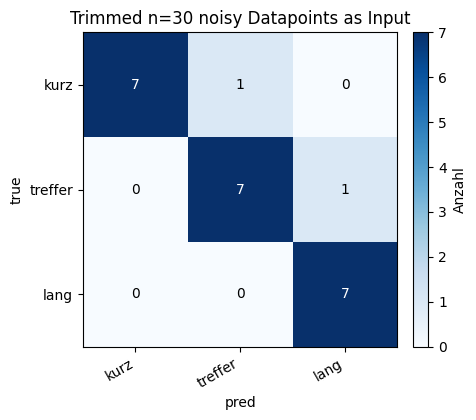

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Trimmed n=30 noisy Datapoints as Input'}, xlabel='pred', ylabel='true'>)

In [39]:
tin = 30

# --- roll-until-ring ohne GT-Horizont: fixe Obergrenze für Future-Rollout ---
# (kein T_out = T; stattdessen Sicherheitsgrenze + pred-basierte Ring-Stop-Maske)
T_total = int(df.groupby("wurf_id").size().min())  # sollte konstant sein ("fixed by construction")
max_future_steps = max(0, T_total - tin)
print("T_total:", T_total, "| max_future_steps:", max_future_steps)

dsC_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlC_train = DataLoader(dsC_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlC_val   = DataLoader(dsC_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlC_test  = DataLoader(dsC_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelC = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histC = train_extrap(
    modelC, dlC_train, dlC_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    max_future_steps=max_future_steps
)

# plot_history(histC, "Mode C (extrapolation) - ExtrapSeq2SeqModel")

cmC = eval_extrap(modelC, dlC_test, tin=tin,
    max_future_steps=max_future_steps, split_name="test C")
plot_confusion_matrix(
    cm=cmC,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Trimmed n=30 noisy Datapoints as Input",
)

## 10) Qualitative Plots: Trajektorien (Ground Truth vs Prediction)
Wir plotten pro Modus ein Beispiel aus Test.

Wurf 89 | true label=2 | pred label=2
Tin=50 | dt_n=0.020408 | noisy→(pred) | clean GT


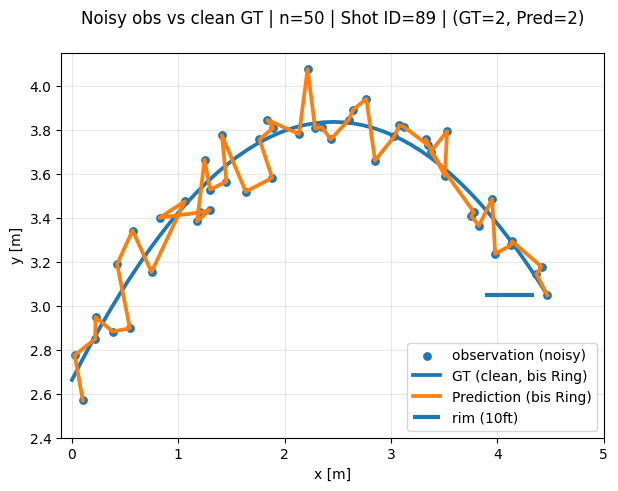

Wurf 1 | true label=1 | pred label=1
Tin=30 | dt_n=0.034483 | input=clean | target(GT)=clean


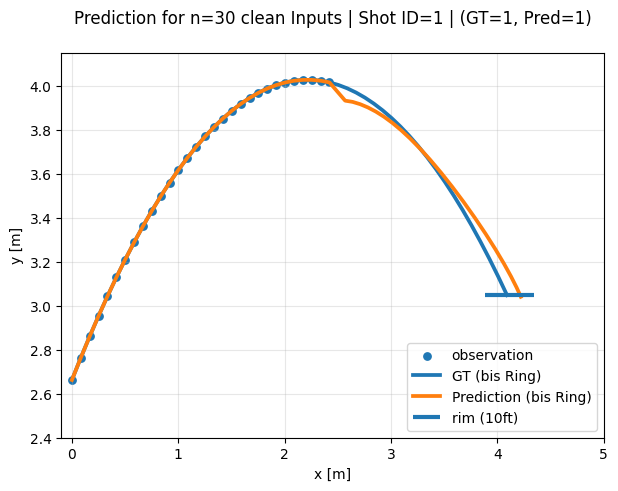

Wurf 71 | true label=2 | pred label=2
Tin=30 | dt_n=0.034483 | noisy→(pred) | clean GT


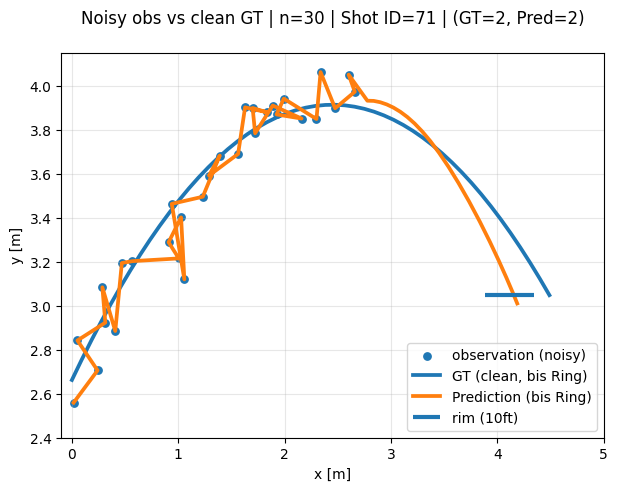

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch


H_RING_M = 3.048  # 10ft in meters (Korbebene)


# --- helper: time normalization exactly like in ExtrapolationDataset ---
def normalize_time_np(t_abs: np.ndarray, t_min: float, denom: float) -> np.ndarray:
    # t_abs: (T,1) float32
    denom = max(1e-8, float(denom))
    return (t_abs - float(t_min)) / denom


def _get_globals_or_raise(model, scaler, device, dg):
    if model is None:
        model = globals().get("model", None)
    if scaler is None:
        scaler = globals().get("scaler", None)
    if device is None:
        device = globals().get("device", None)
    if dg is None:
        dg = globals().get("dg", None)

    missing = [
        name
        for name, obj in [("model", model), ("scaler", scaler), ("device", device)]
        if obj is None
    ]
    if missing:
        raise RuntimeError(
            f"Fehlt im Scope: {missing}. Übergib sie als Parameter oder setze globale Variablen."
        )
    return model, scaler, device, dg


def _ring_crossing_idx_np(y: np.ndarray, y_ring: float = H_RING_M) -> int:
    """Erstes absteigendes Crossing y<=y_ring nach Apex. y: (T,) in Metern."""
    T = len(y)
    apex = int(np.argmax(y))
    for k in range(apex + 1, T):
        if (y[k] <= y_ring) and (y[k - 1] > y_ring):
            return k
    return T - 1


def _build_from_ds_groups(
    ds,
    scaler,
    idx: int,
    n_obs: int | None = None,
    input_source: str | None = None,
    target_source: str | None = None,
):
    """Baut alle Arrays/Tensors wie im Dataset, aber erlaubt n_obs override.

    Gibt zusätzlich unskalierte XYs in Metern fürs Plotten zurück.
    """
    wid = ds.throw_ids[idx]
    g = ds.groups[wid]

    T = len(g)
    Tin = int(n_obs) if n_obs is not None else int(ds.tin)
    assert 1 <= Tin <= T, f"Tin/n_obs={Tin} ist ungültig für T={T}"

    in_src = input_source if input_source is not None else ds.input_source
    tg_src = target_source if target_source is not None else ds.target_source

    # raw (meters)
    t_abs = g["t"].to_numpy(np.float32)[:, None]  # (T,1)
    xy_clean = g[["x_clean", "y_clean"]].to_numpy(np.float32)  # (T,2)
    xy_noisy = g[["x_noisy", "y_noisy"]].to_numpy(np.float32)  # (T,2)

    xy_in_m = xy_noisy if in_src == "noisy" else xy_clean  # for plotting obs
    xy_gt_m = xy_clean if tg_src == "clean" else xy_noisy  # for plotting GT

    # time norm (no future knowledge): denom based on last observed time
    t_min = float(t_abs[0, 0])
    t_obs_max = float(t_abs[Tin - 1, 0])
    denom = max(1e-8, (t_obs_max - t_min))
    t_n = normalize_time_np(t_abs, t_min, denom).astype(np.float32)  # (T,1)

    # Δt ausschließlich aus Beobachtungsfenster
    if Tin >= 2:
        dt_n = float(np.mean(np.diff(t_n[:Tin, 0])))
    else:
        dt_n = 0.0

    # scale XY like training
    xy_in_s = scaler.transform(xy_in_m)  # (T,2)
    xy_gt_s = scaler.transform(xy_gt_m)  # (T,2)

    # model tensors (match ExtrapolationDataset)
    x_in = np.concatenate([xy_in_s[:Tin], t_n[:Tin]], axis=1).astype(np.float32)  # (Tin,3)
    y_all = xy_gt_s.astype(np.float32)  # (T,2)

    # ring height in scaled space
    y_ring_scaled = (H_RING_M - float(scaler.mean_[0, 1])) / float(scaler.std_[0, 1])

    label = int(g["label"].iloc[0])

    return {
        "wurf_id": wid,
        "label": label,
        "Tin": Tin,
        "T": T,
        "t_min": t_min,
        "denom": float(denom),
        "dt_n": dt_n,
        "xy_obs_m": xy_in_m[:Tin],  # (Tin,2) meters
        "xy_gt_m": xy_gt_m,         # (T,2) meters
        "x_in": torch.from_numpy(x_in),          # (Tin,3)
        "dt": torch.tensor([dt_n], dtype=torch.float32),  # (1,)
        "y_all": torch.from_numpy(y_all),        # (T,2)
        "y_ring_scaled": torch.tensor([y_ring_scaled], dtype=torch.float32),  # (1,)
        "input_source": in_src,
        "target_source": tg_src,
    }


@torch.no_grad()
def demo_reconstruction(
    ds,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
    max_steps=300,
):
    """Qualitative Demo (ohne t_all): Rollout dynamisch bis Korbebene."""
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    s = _build_from_ds_groups(ds, scaler, idx=idx, n_obs=n_obs)
    wid = s["wurf_id"]

    model.eval()

    # dynamischer Rollout bis Ring (nur falls Zukunftsschritte benötigt werden)
    if (max_steps is None) or (int(max_steps) <= 0) or (s["Tin"] >= s["T"]):
        y_future = torch.zeros((1, 0, 2), device=device)
        stop_idx = torch.tensor([-1], device=device)
        S = 0
    else:
        y_future, stop_idx, S = model.rollout_until_ring(
            s["x_in"].unsqueeze(0).to(device),
            s["dt"].unsqueeze(0).to(device),
            s["y_ring_scaled"].unsqueeze(0).to(device),
            max_steps=max_steps,
        )
    y_future = y_future.squeeze(0)  # (S,2)

    # label prediction (aus Encoder-Kontext)
    _, logits = model(s["x_in"].unsqueeze(0).to(device), s["dt"].unsqueeze(0).to(device), n_future=0)
    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(s["label"])

    # inverse scale preds to meters
    y_future_m = scaler.inverse_transform(y_future.cpu().numpy())  # (S,2)

    # build full pred curve: observed + future
    xy_pred_m = np.vstack([s["xy_obs_m"], y_future_m])

    # GT until ring
    k_stop_gt = _ring_crossing_idx_np(s["xy_gt_m"][:, 1], y_ring=H_RING_M)
    xy_gt_cut = s["xy_gt_m"][: k_stop_gt + 1]

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(f"Tin={s['Tin']} | dt_n={s['dt_n']:.6f} | input={s['input_source']} | target(GT)={s['target_source']}")

    plt.figure(figsize=(7, 5))
    plt.scatter(s["xy_obs_m"][:, 0], s["xy_obs_m"][:, 1], s=28, label="observation")
    plt.plot(xy_gt_cut[:, 0], xy_gt_cut[:, 1], linewidth=2.7, label="GT (bis Ring)")
    plt.plot(xy_pred_m[:, 0], xy_pred_m[:, 1], linewidth=2.7, label="Prediction (bis Ring)")
    plt.hlines(
        y=H_RING_M,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )

    plt.title(
        f"Prediction for n={s['Tin']} {s['input_source']} Inputs | "
        f"Shot ID={wid} | (GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(
    ds_noisy,
    ds_clean,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
    max_steps=300,
):
    """Noisy-Obs vs Clean-GT Demo (ohne t_all): Rollout dynamisch bis Korbebene."""
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    # sample from noisy ds
    sN = _build_from_ds_groups(
        ds_noisy,
        scaler,
        idx=idx,
        n_obs=n_obs,
        input_source="noisy",
        target_source=ds_noisy.target_source,
    )
    wid = sN["wurf_id"]

    # build index cache for ds_clean by wurf_id
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {ds_clean.throw_ids[j]: j for j in range(len(ds_clean))}
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wid not in clean_index:
        raise KeyError(f"wurf_id={wid} nicht im ds_clean gefunden. Prüfe Split/IDs.")

    sC = _build_from_ds_groups(ds_clean, scaler, idx=clean_index[wid], n_obs=n_obs, input_source="clean", target_source="clean")

    # dynamischer Rollout aus noisy Input bis Ring (nur falls Zukunftsschritte benötigt werden)
    if (max_steps is None) or (int(max_steps) <= 0) or (sN["Tin"] >= sN["T"]):
        y_future = torch.zeros((1, 0, 2), device=device)
        stop_idx = torch.tensor([-1], device=device)
        S = 0
    else:
        y_future, stop_idx, S = model.rollout_until_ring(
            sN["x_in"].unsqueeze(0).to(device),
            sN["dt"].unsqueeze(0).to(device),
            sN["y_ring_scaled"].unsqueeze(0).to(device),
            max_steps=max_steps,
        )
    y_future = y_future.squeeze(0)
    y_future_m = scaler.inverse_transform(y_future.cpu().numpy())

    xy_pred_m = np.vstack([sN["xy_obs_m"], y_future_m])

    # GT clean bis Ring
    k_stop_gt = _ring_crossing_idx_np(sC["xy_gt_m"][:, 1], y_ring=H_RING_M)
    xy_gt_cut = sC["xy_gt_m"][: k_stop_gt + 1]

    # class pred
    _, logits = model(sN["x_in"].unsqueeze(0).to(device), sN["dt"].unsqueeze(0).to(device), n_future=0)
    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(sN["label"])

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(f"Tin={sN['Tin']} | dt_n={sN['dt_n']:.6f} | noisy→(pred) | clean GT")

    plt.figure(figsize=(7, 5))
    plt.scatter(sN["xy_obs_m"][:, 0], sN["xy_obs_m"][:, 1], s=28, label="observation (noisy)")
    plt.plot(xy_gt_cut[:, 0], xy_gt_cut[:, 1], linewidth=2.7, label="GT (clean, bis Ring)")
    plt.plot(xy_pred_m[:, 0], xy_pred_m[:, 1], linewidth=2.7, label="Prediction (bis Ring)")
    plt.hlines(
        y=H_RING_M,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )

    plt.title(
        f"Noisy obs vs clean GT | n={sN['Tin']} | Shot ID={wid} | (GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()


demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsA_test,
    ds_clean=dsA_clean_test,
    idx=14,
    n_obs=50,
    model=modelA,
    scaler=scaler,
    device=device,
)

demo_reconstruction(
    ds=dsB_test,
    idx=0,
    n_obs=30,
    model=modelB,
    scaler=scaler,
    device=device,
)

demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsC_test,
    ds_clean=dsA_clean_test,
    idx=11,
    n_obs=30,
    model=modelC,
    scaler=scaler,
    device=device,
)
